In [4]:
from latent_dubins_gap_ddpg import LatentDubinGap, get_args, state_to_image_pil_hq
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from colorama import Fore, Back, Style
import matplotlib.colors as mcolors
from IPython.display import display, clear_output

class DubinEnv():
    def __init__(self, start_state, goal_state):
        self.start_state = start_state
        self.curr_state = start_state
        self.goal_state = goal_state
        self.args = get_args()
        self.v = self.args.speed
        self.dt = self.args.dt

    def forward(self, action):
        # Apply the action to the current state
        state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
        pstate = self.curr_state.copy()
        pstate[0] += self.v * np.cos(self.curr_state[2]) * self.dt
        pstate[1] += self.v * np.sin(self.curr_state[2]) * self.dt
        pstate[2] += action * self.dt  # Update the heading angle
        img = state_to_image_pil_hq(pstate, self.args)

        state_obs.append(pstate[2]) # get to observe theta
        state_gt.append(pstate) # gt state
        dones.append(1)
        acs.append(action)
        img_obs.append(img)

        demo = {}
        demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
        demo['actions'] = acs
        demo['dones'] = dones
        return demo, pstate
    
    def goal_ref(self):
        # Calculate the direction towards the goal
        dx = self.goal_state[0] - self.curr_state[0]
        dy = self.goal_state[1] - self.curr_state[1]
        angle_to_goal = np.arctan2(dy, dx)
        ref_theta = angle_to_goal
        delta_theta = ref_theta - self.curr_state[2]
        # Normalize the angle to be within [-pi, pi] using modulo operation
        delta_theta = (delta_theta + np.pi) % (2 * np.pi) - np.pi
        ref_theta_dot = (delta_theta) / self.dt

        return ref_theta, np.clip(ref_theta_dot, -self.args.turnRate, self.args.turnRate)

to_np = lambda x: x.cpu().detach().numpy()


## CBF on Latent Dubins

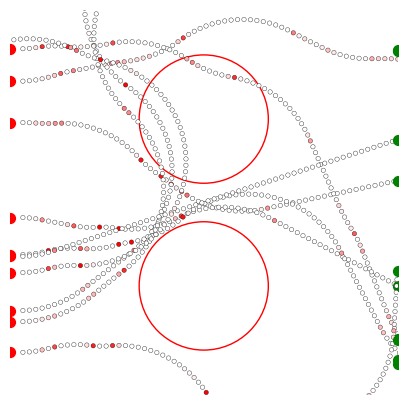

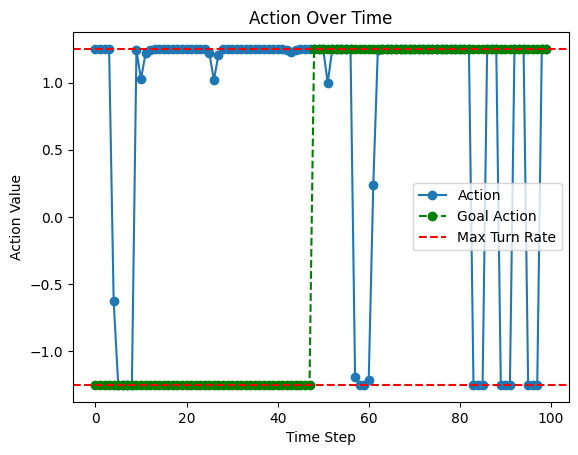

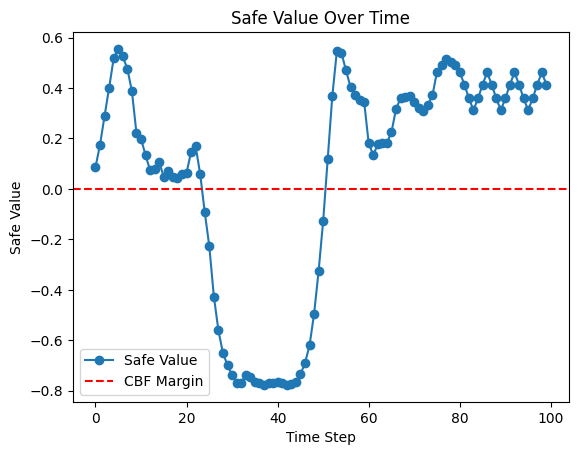

In [19]:

brt = LatentDubinGap()
# plot the trajectory history and circle obstacle
fig, ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
for x_obs, y_obs, r_obs in zip(brt.args.obs_x, brt.args.obs_y, brt.args.obs_r):
    circle = patches.Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

for i in range(10):

    num1 = np.random.uniform(-1.3, 1.3)
    num2 = np.random.uniform(-1.3, 1.3)

    start_state = np.array([-1.5, num1, 0])  #
    goal_state = np.array([1.5, num2, 0])  #(x, y, theta)

    dubin_env = DubinEnv(start_state=start_state,
                            goal_state=goal_state)

    print(f"Start State: {start_state}, Goal State: {goal_state}")

    priv_states = []
    actions = []
    goal_actions = []
    current_safe = []
    safe_values = []

    epsilon = 0.4
    gamma = 0.75
    simlen = 100
    u_min = -dubin_env.args.turnRate
    u_max = dubin_env.args.turnRate
    u_samples = 1000
    u_delta = (u_max - u_min) / u_samples
    u_range = np.arange(u_min, u_max + u_delta, u_delta)  # action range for Dubins car
    u_range = torch.tensor(u_range, dtype=torch.float32, device=brt.args.device).unsqueeze(-1)  # Convert to tensor

    demo, priv_state = dubin_env.forward(0) # initialize with zero action
    feat = brt.data_to_feat(demo)           # render state (took another step in wm)
    Vz = brt.evaluate_V(to_np(feat))[0]
    Lz = brt.margin_fn(feat)[0][0][0]
    safe_value = np.min([Vz, to_np(Lz)])  
    demo, priv_state = dubin_env.forward(0) # take real step to match wm step
    dubin_env.curr_state = priv_state       # take another step in real
    # at this point, Vz should indicate value of current state 

    for i in range(simlen):
        # get goal reference direction and action
        goal_dir, goal_act = dubin_env.goal_ref()
        curr_safe = 1 

        Qzs = brt.evaluate_Q(to_np(feat), u_range)
        # print(f"Qzs: {Qzs}")
        # cbf_cond = Qzs > gamma * Vz
        cbf_cond = Qzs > max(gamma * max(Vz, epsilon), epsilon)
        # print(f"CBF Condition: {cbf_cond}")
        Qzs_valid_idx = np.where(cbf_cond)[0]
        # print(f"u_range: {u_range.squeeze(-1).detach().cpu().numpy()}")

        if Qzs_valid_idx.size == 0:
            # print(Fore.RED + "No valid actions found, using goal action."+Style.RESET_ALL)
            # action = goal_act
            safe_action = brt.find_a(feat.detach().cpu().numpy())
            action = safe_action[0]
        else:
            # Find the action that maximizes the Q-value while satisfying the CBF condition
            Qzs_valid = Qzs[Qzs_valid_idx]
            # Find the action that minimizes the distance to the goal action
            affordable_actions = torch.abs(u_range.squeeze(-1).masked_fill(torch.tensor(~cbf_cond, device=u_range.device), torch.inf) - goal_act)
            # print(f"Affordable actions: {affordable_actions}")
            closest_action = torch.argmin(affordable_actions)
            # print(f"Closest action index: {closest_action}, Value: {Qzs[closest_action]}, Goal Action: {goal_act}")
            action = u_range[closest_action][0].detach().cpu().numpy()

        feat = brt.data_to_feat(demo, action=action) # take action in wm
        demo, priv_state = dubin_env.forward(action) # take action in real
        Vz = brt.evaluate_V(to_np(feat))[0] # Vz after action
        Lz = brt.margin_fn(feat)[0][0][0]
        safe_value = np.min([Vz, to_np(Lz)])   
        dubin_env.curr_state = priv_state  # update state after taking action

        priv_states.append(priv_state)
        actions.append(action)
        goal_actions.append(goal_act)
        current_safe.append(curr_safe)
        safe_values.append(safe_value)

        distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])
        # print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
        #     f"Goal: {np.round(goal_dir,2)}, "
        #     f"Action: {np.around(action,2)}, "
        #     f"Dist: {np.round(distance,2)}, "
        #     f"Safe Value: {np.round(safe_value, 2)}")
        
        if distance < 0.05:
            print("Reached the goal!")
            break

    # plot: black edge for trajectory points, red for intervention
    # plot: white to red gradient for delta action magnitude
    delta_action = np.abs(np.diff(np.array(actions), prepend=actions[0]))
    colors = ["white", "red"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("white_red", colors)
    norm = mcolors.Normalize(vmin=0, vmax=u_max - u_min)

    pss = np.array(priv_states)

    ax.scatter(pss[:,0], pss[:,1], c=delta_action, s=10, label='Trajectory', cmap=custom_cmap, norm=norm, edgecolor='black', linewidth=0.25)
    ax.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')
    ax.scatter(start_state[0], start_state[1], c='red', s=50, label='Start')
    
    clear_output(wait=True)
    display(fig)

    # plot action over time
    plt.figure()
    plt.plot(np.array(actions), label='Action', marker='o')
    plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
    plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
    plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
    plt.xlabel('Time Step')
    plt.ylabel('Action Value')
    plt.title('Action Over Time')
    plt.legend()
    plt.show()

    # plot safe value over time
    plt.figure()
    plt.plot(safe_values, label='Safe Value', marker='o')
    plt.axhline(y=0, color='r', linestyle='--', label='CBF Margin')
    plt.xlabel('Time Step')
    plt.ylabel('Safe Value')
    plt.title('Safe Value Over Time')
    plt.legend()
    plt.show()


## LRSF on Latent Dubins

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 25916421 trainable variables (excluding margin heads).
Optimizer margin_nogp has 543233 trainable variables.
Optimizer margin_gp has 543233 trainable variables.
Start State: [-1.5       -0.7313011  0.       ], Goal State: [ 1.5        -0.69575982  0.        ]
Step 1: Pstate: [-1.4  -0.73  0.06], Goal: 0.01, Action: 1.25, Dist: 2.9, Safe Value: 0.05999999865889549
Optimizer model_opt has 25916421 trainable variables (excluding margin heads).
Optimizer margin_nogp has 543233 trainable variables.
Optimizer margin_gp has 543233 trainable variables.
Start State: [-1.5       -0.7313011  0.       ], Goal State: [ 1.5        -0.69575982  0.        ]
Step 1: Pstate: [-1.4  -0.73  0.06], Goal: 0.01, Action: 1.25, Dist: 2.9, Safe Value: 0.05999999865889549
Step 2: Pstate: [-1.35 -0.73  0.12], Goal: 0.01, A

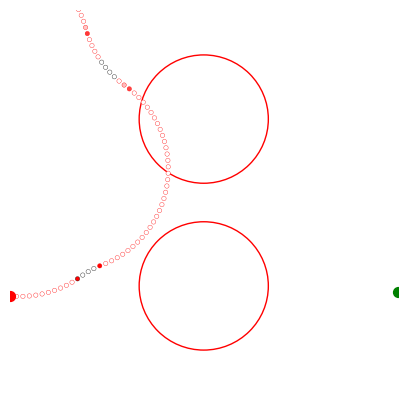

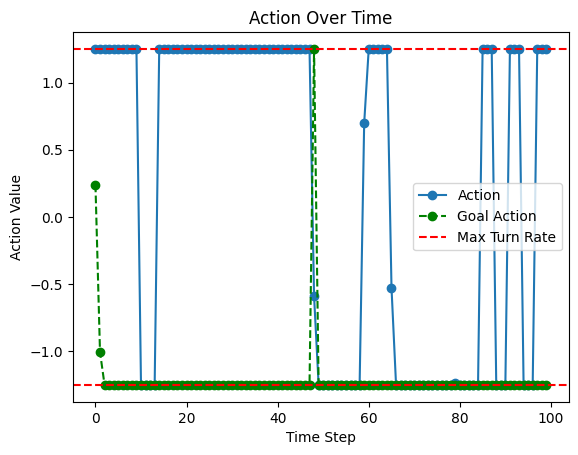

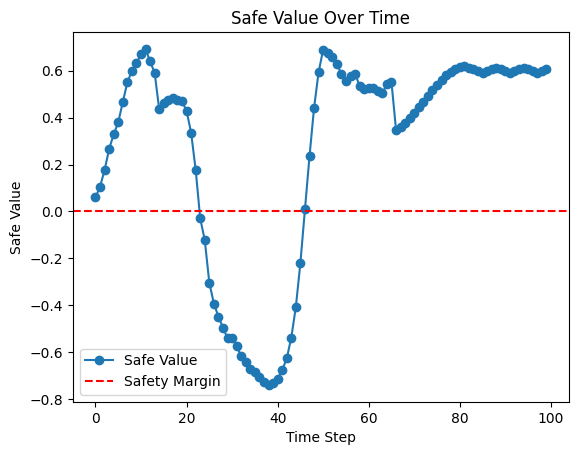

In [24]:

brt = LatentDubinGap()
# plot the trajectory history and circle obstacle 
fig,ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
for x_obs, y_obs, r_obs in zip(brt.args.obs_x, brt.args.obs_y, brt.args.obs_r):
    circle = patches.Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

for i in range(1):
    num1 = np.random.uniform(-1.3, 1.3)
    num2 = np.random.uniform(-1.3, 1.3)

    start_state = np.array([-1.5, num1, 0])  #
    goal_state = np.array([1.5, num2, 0])  #(x, y, theta)

    dubin_env = DubinEnv(start_state=start_state,
                            goal_state=goal_state)
    
    print(f"Start State: {start_state}, Goal State: {goal_state}")

    priv_states = []
    actions = []
    goal_actions = []
    current_safe = []
    safe_values = []

    epsilon = 0.6
    simlen = 100
    u_min = -dubin_env.args.turnRate
    u_max = dubin_env.args.turnRate

    demo, priv_state = dubin_env.forward(0) # initialize with zero action
    feat = brt.data_to_feat(demo)           # render state (took another step in wm)
    Vz = brt.evaluate_V(to_np(feat))[0]
    Lz = brt.margin_fn(feat)[0][0][0]
    safe_value = np.min([Vz, to_np(Lz)])  
    demo, priv_state = dubin_env.forward(0) # take real step to match wm step
    dubin_env.curr_state = priv_state       # take another step in real
    # at this point, Vz should indicate value of current state 

    for i in range(simlen):
        # get goal reference direction and action
        goal_dir, goal_act = dubin_env.goal_ref()    
        curr_safe = 1 

        if safe_value < epsilon: 
            safe_action = brt.find_a(feat.detach().cpu().numpy())
            action = safe_action[0]
            curr_safe = 0 # when safe action is engaged
            # print(Fore.RED + 'Safe action engaged!' + Style.RESET_ALL)
        else:
            action = goal_act # nominal action otherwise
        
        priv_states.append(priv_state)
        actions.append(action)
        goal_actions.append(goal_act)
        current_safe.append(curr_safe)
        
        feat = brt.data_to_feat(demo, action=action) # take action in wm
        demo, priv_state = dubin_env.forward(action) # take action in real
        Vz = brt.evaluate_V(to_np(feat))[0] # Vz after action
        Lz = brt.margin_fn(feat)[0][0][0]
        safe_value = np.min([Vz, to_np(Lz)])   
        dubin_env.curr_state = priv_state  # update state after taking action
        
        safe_values.append(safe_value)
        distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])

        print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
            f"Goal: {np.round(goal_dir,2)}, "
            f"Action: {np.around(action,2)}, "
            f"Dist: {np.round(distance,2)}, "
            f"Safe Value: {np.round(safe_value, 3)}")
        
        if distance < 0.05:
            print("Reached the goal!")
            break

    # plot: black edge for trajectory points, red for intervention
    # plot: white to red gradient for delta action magnitude
    delta_action = np.abs(np.diff(np.array(actions), prepend=actions[0]))
    colors = ["white", "red"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("white_red", colors)
    norm = mcolors.Normalize(vmin=0, vmax=u_max - u_min)

    pss = np.array(priv_states)
    safe_action_idx = np.where(np.array(current_safe) == 1)
    unsafe_action_idx = np.where(np.array(current_safe) == 0)
    ax.scatter(pss[safe_action_idx][:,0], pss[safe_action_idx][:,1], c=delta_action[safe_action_idx], s=10, label='Trajectory', cmap=custom_cmap, norm=norm, linewidths=0.25, edgecolor='black')
    ax.scatter(pss[unsafe_action_idx][:,0], pss[unsafe_action_idx][:,1], c=delta_action[unsafe_action_idx], s=10, label='Trajectory', cmap=custom_cmap, norm=norm, linewidths=0.25, edgecolor='red')
    ax.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')
    ax.scatter(start_state[0], start_state[1], c='red', s=50, label='Start')

    # clear_output(wait=True)
    # display(fig)

    # plot action over time
    plt.figure()
    plt.plot(np.array(actions), label='Action', marker='o')
    plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
    plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
    plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
    plt.xlabel('Time Step')
    plt.ylabel('Action Value')
    plt.title('Action Over Time')
    plt.legend()
    plt.show()
        
    plt.figure()
    plt.plot(safe_values, label='Safe Value', marker='o')
    plt.axhline(y=0, color='r', linestyle='--', label='Safety Margin')
    plt.xlabel('Time Step')
    plt.ylabel('Safe Value')
    plt.title('Safe Value Over Time')
    plt.legend()
    plt.show()
